# 33 — `sankey`

`Map.sankey` draws a **spatial flow map**: line features whose *width* is proportional to a magnitude. It is the
map for anything that moves along a network and accumulates — traffic on roads, discharge down a river, trade
between ports — because width is the channel a reader interprets as "how much" without being told.

Where `lines` puts value in colour, `sankey` puts it in thickness, which survives greyscale printing and reads
correctly at a glance.

API: [`Map.sankey`](../../reference/static_map.md).

> **Where this data comes from.** Everything in this notebook is real, downloaded with
> [earthlens](https://github.com/serapeum-org/earthlens) and committed under `examples/data/`.
> `examples/data/ATTRIBUTION.md` records each source and its licence.


**Setup**.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits three levels up: docs/examples/plots -> repo root.
DATA = Path("../../../examples/data")

# UTM zone 32N: a metric CRS, correct for south-west Germany. Distance-based
# renders (Voronoi, hex lattices, kernels) must not be computed in degrees.
UTM32 = 25832


## The data

The same 2,320 **OpenStreetMap** road centrelines. `lanes` is the magnitude: a six-lane road really does carry
more than a one-lane street, so lane count is a genuine measure of capacity rather than a stand-in for one.

In [2]:
roads = FeatureCollection.read_file(str(DATA / "heidelberg_roads.geojson"))
laned = FeatureCollection(roads.dropna(subset=["lanes"]))
print(f"{len(laned)} of {len(roads)} roads carry a lane count")
laned["lanes"].value_counts().sort_index()

1476 of 2320 roads carry a lane count


lanes
1.0    413
2.0    813
3.0    176
4.0     57
5.0     16
6.0      1
Name: count, dtype: int64

1,476 roads tagged, from one lane to six. The rest are untagged and excluded — a flow map of unknown magnitudes
would be a fiction.

## Quickstart — width as magnitude

`column=` is the magnitude that sets each line's width.

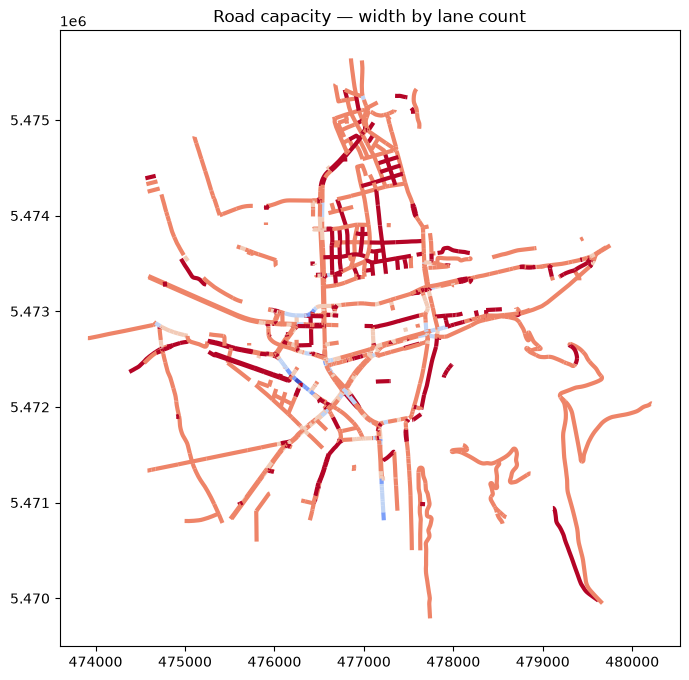

In [3]:
m = Map(crs=UTM32, figsize=(8, 8))
m.sankey(laned, column="lanes")
m.set_title("Road capacity — width by lane count")
m.fig;

The multi-lane arterials and the bridge approaches now stand out as thick ribbons, with the single-lane
residential streets as threads. Compare this with `32_lines`' colour ramp: the information is similar, but
thickness is read pre-attentively — you see the trunk route before deciding to look for it.

## Width and colour together

`column` sets width; `scale` names the column driving colour, so one figure can carry two variables — or the same
one twice for emphasis.

| argument | meaning | typical value |
|---|---|---|
| `features` | the line collection | a line `FeatureCollection` |
| `column` | magnitude driving **width** | a numeric column |
| `scale` | column driving **colour** | often the same column |

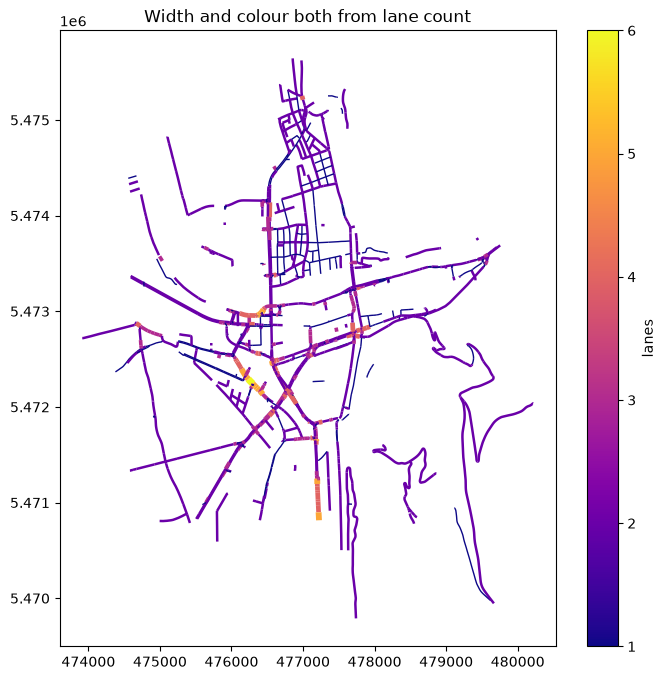

In [4]:
m = Map(crs=UTM32, figsize=(8, 8))
m.sankey(laned, column="lanes", scale="lanes", cmap="plasma")
m.colorbar(label="lanes")
m.set_title("Width and colour both from lane count")
m.fig;

Doubling width and colour onto one variable is redundant encoding, and that is a feature: a reader who cannot
separate the colours still sees the thickness, and vice versa.

## Two variables at once

Width and colour can also carry different things — capacity and speed, say, which is how you spot a wide road
with a low limit or a narrow one with a high one.

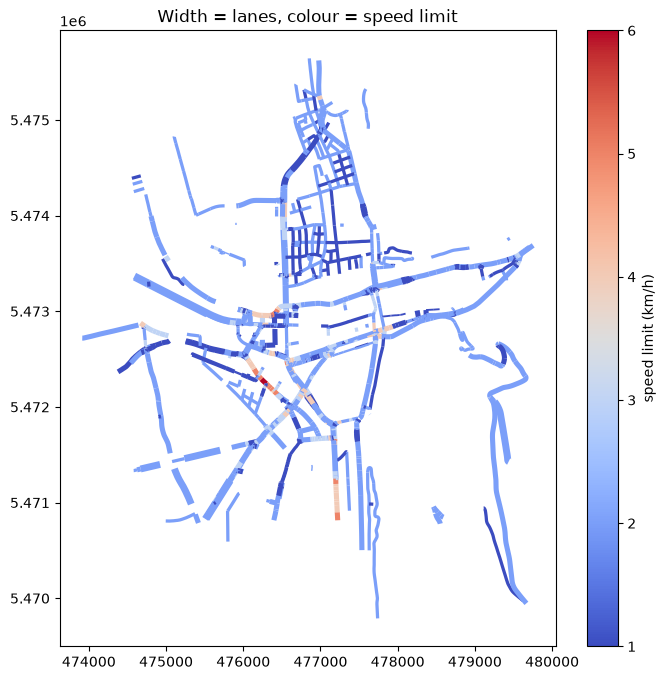

In [5]:
both = FeatureCollection(laned.dropna(subset=["maxspeed"]))
m = Map(crs=UTM32, figsize=(8, 8))
m.sankey(both, column="lanes", scale="maxspeed", cmap="coolwarm")
m.colorbar(label="speed limit (km/h)")
m.set_title("Width = lanes, colour = speed limit")
m.fig;

The thick blue ribbons through the centre are wide but slow — city arterials with a 30 km/h limit. The thin red
lines are narrow and fast, on the edge of town. Neither figure above could show that pairing.

## Takeaway

- `sankey` puts magnitude in **line width**, the channel readers read as quantity without instruction.
- `column` drives width, `scale` drives colour: one variable for redundancy, two to layer them.
- Drop features with no magnitude rather than letting them default — a flow map of guesses is worse than a
  smaller one.
- Prefer `sankey` over `lines(column=...)` whenever the value is a *flow* or a *capacity*.

Next: [`34_labels`](34_labels.ipynb) puts text from an attribute onto the map.